#**Підготовка даних та ключові бізнес-показники**

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

%cd /content/drive/MyDrive/Final_project


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Final_project


In [ ]:
import pandas as pd

events = pd.read_csv('events.csv')
products = pd.read_csv('products.csv')
countries = pd.read_csv('countries.csv')

print(events.info())
print(products.head())
print(countries.head())
df['Order Date'] = pd.to_datetime(df['Order Date'])

df['YearMonth'] = df['Order Date'].dt.to_period('M').dt.to_timestamp()





<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB
None
     id        item_type
0  2103           Cereal
1  7940        Household
2  2455          Clothes
3  1270        Beverages
4  8681  Office Supplies
             name alpha-2 alpha-3   region       sub-region
0     Afghanistan      AF     AFG     Asia    Southern Asia
1   Åland Isla

In [ ]:
import pandas as pd
import numpy as np
print("--- Аналіз та обробка пропусків ---")
for name, df in [('events', events), ('products', products), ('countries', countries)]:
    null_counts = df.isnull().sum()
    if null_counts.sum() > 0:
        print(f"\nТаблиця {name}:")
        print(null_counts[null_counts > 0])
    else:
        print(f"\nТаблиця {name}: пропусків немає")
events['Units Sold'] = events['Units Sold'].fillna(events['Units Sold'].median())
events['Country Code'] = events['Country Code'].fillna('Unknown')
print("\n--- Коригування типів даних ---")
events['Order Date'] = pd.to_datetime(events['Order Date'], errors='coerce')
events['Ship Date'] = pd.to_datetime(events['Ship Date'], errors='coerce')
events['Units Sold'] = pd.to_numeric(events['Units Sold'], errors='coerce')
events['Unit Price'] = pd.to_numeric(events['Unit Price'], errors='coerce')
print("\n--- Обробка дублікатів та очищення тексту ---")
def clean_text(df):
    text_cols = df.select_dtypes(include=['object']).columns
    for col in text_cols:
        df[col] = df[col].astype(str).str.strip().str.title()
    return df

events = clean_text(events)
products = clean_text(products)
countries = clean_text(countries)
print(f"Дублікатів у events: {events.duplicated().sum()}")
events = events.drop_duplicates()
print("\n--- Перевірка на аномалії ---")
anomalies = events[(events['Units Sold'] <= 0) | (events['Unit Price'] <= 0)]
if not anomalies.empty:
    print(f"Знайдено рядків з від'ємними/нульовими значеннями: {len(anomalies)}")
    events = events[events['Units Sold'] > 0]
print(events[['Units Sold', 'Unit Price', 'Unit Cost']].describe())

print("\nОчищення завершено успішно!")

--- Аналіз та обробка пропусків ---

Таблиця events:
Country Code    82
Units Sold       2
dtype: int64

Таблиця products: пропусків немає

Таблиця countries:
alpha-2       1
region        1
sub-region    1
dtype: int64

--- Коригування типів даних ---

--- Обробка дублікатів та очищення тексту ---
Дублікатів у events: 0

--- Перевірка на аномалії ---
        Units Sold   Unit Price    Unit Cost
count  1330.000000  1330.000000  1330.000000
mean   4952.216541   264.893541   187.246812
std    2903.012194   217.323460   176.158873
min       2.000000     9.330000     6.920000
25%    2360.750000    81.730000    35.840000
50%    4962.000000   154.060000    97.440000
75%    7458.750000   437.200000   263.330000
max    9999.000000   668.270000   524.960000

Очищення завершено успішно!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

events = pd.read_csv('events.csv')
products = pd.read_csv('products.csv')
countries = pd.read_csv('countries.csv')

events['Order Date'] = pd.to_datetime(events['Order Date'])
events['Ship Date'] = pd.to_datetime(events['Ship Date'])

events['Shipment Delay'] = (events['Ship Date'] - events['Order Date']).dt.days
events = events[events['Shipment Delay'] >= 0]

df = events.merge(countries, left_on='Country Code', right_on='alpha-3', how='left')
df = df.merge(products, left_on='Product ID', right_on='id', how='left')

df = df.drop(columns=[
    'alpha-2','alpha-3','sub-region','Order Priority'
], errors='ignore')

df = df.rename(columns={
    'name':'country',
    'region':'region',
    'item_type':'category',
    'Sales Channel':'channel'
})

df['Revenue'] = df['Units Sold'] * df['Unit Price']
df['Cost'] = df['Units Sold'] * df['Unit Cost']
df['Profit'] = df['Revenue'] - df['Cost']

df.head()

total_orders = df['Order ID'].nunique()
total_revenue = df['Revenue'].sum()
total_profit = df['Profit'].sum()
countries_count = df['country'].nunique()
avg_order_value = total_revenue / total_orders
avg_delivery = df['Shipment Delay'].mean()

print(f"Кількість замовлень: {total_orders}")
print(f"Загальний дохід: {total_revenue:,.0f}")
print(f"Загальний прибуток: {total_profit:,.0f}")
print(f"Кількість країн: {countries_count}")
print(f"Середній чек: {avg_order_value:,.2f}")
print(f"Середня доставка (дні): {avg_delivery:.2f}")



Кількість замовлень: 1330
Загальний дохід: 1,702,129,408
Загальний прибуток: 501,434,459
Кількість країн: 45
Середній чек: 1,279,796.55
Середня доставка (дні): 24.78


#**АНАЛІЗ ПРОДАЖІВ**

##**Категорії товарів**

Дохід по категоріях

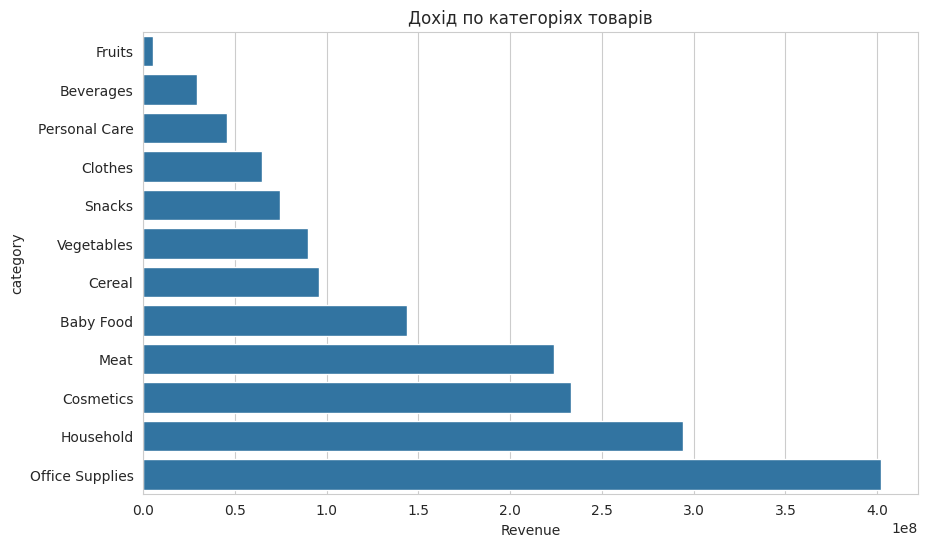

In [ ]:
plt.figure(figsize=(10,6))
cat_rev = df.groupby('category')['Revenue'].sum().sort_values()
sns.barplot(x=cat_rev.values, y=cat_rev.index)
plt.title('Дохід по категоріях товарів')
plt.xlabel('Revenue')
plt.show()

Прибуток по категоріях

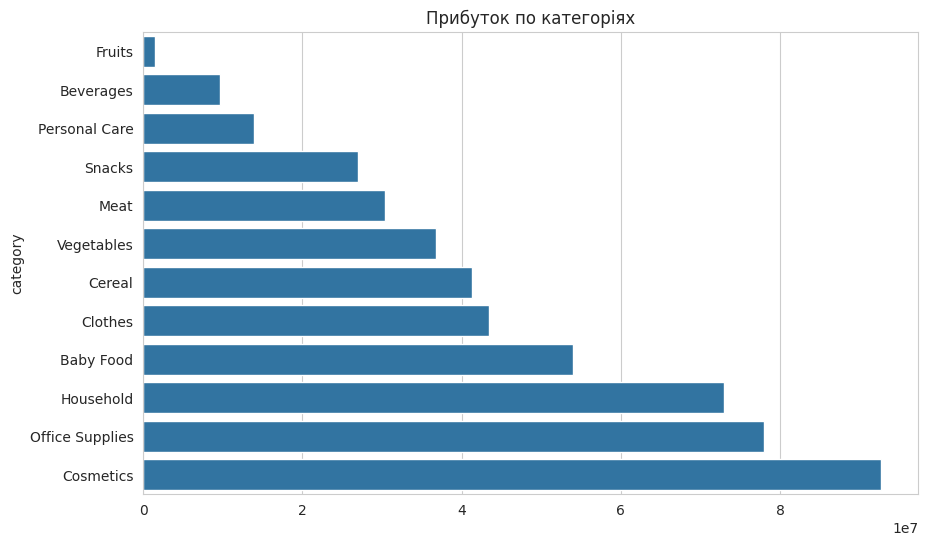

In [ ]:
plt.figure(figsize=(10,6))
cat_profit = df.groupby('category')['Profit'].sum().sort_values()
sns.barplot(x=cat_profit.values, y=cat_profit.index)
plt.title('Прибуток по категоріях')
plt.show()

Популярність товарів

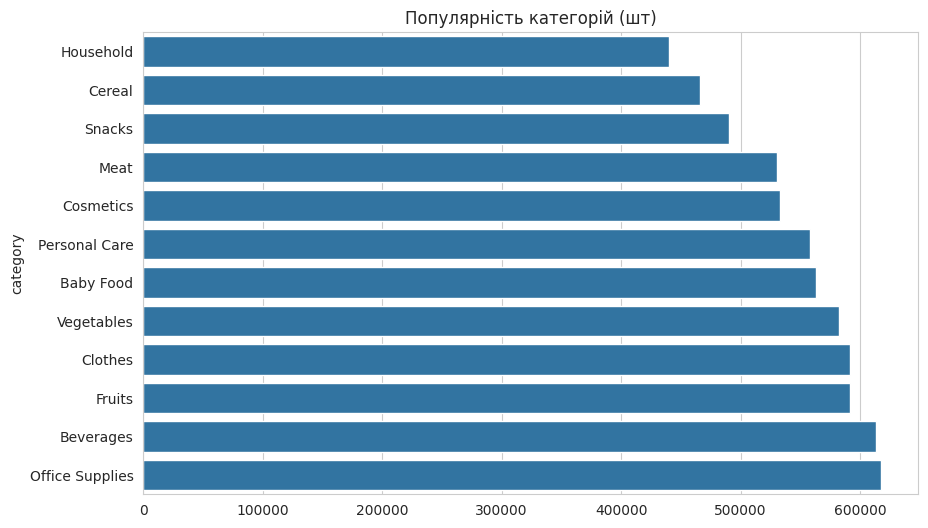

In [ ]:
plt.figure(figsize=(10,6))
cat_units = df.groupby('category')['Units Sold'].sum().sort_values()
sns.barplot(x=cat_units.values, y=cat_units.index)
plt.title('Популярність категорій (шт)')
plt.show()

#**Географія**

Прибуток по регіонах

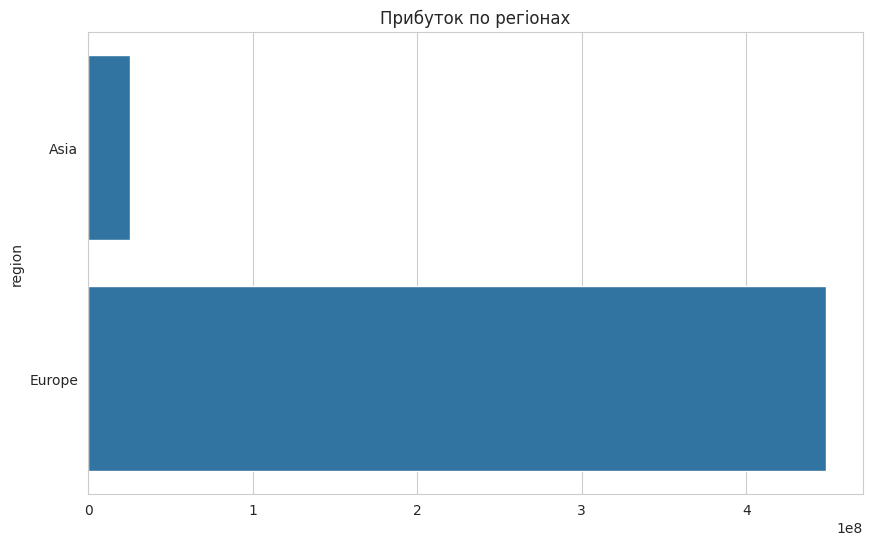

In [ ]:
plt.figure(figsize=(10,6))
region_profit = df.groupby('region')['Profit'].sum().sort_values()
sns.barplot(x=region_profit.values, y=region_profit.index)
plt.title('Прибуток по регіонах')
plt.show()

ТОП-10 країн по доходу

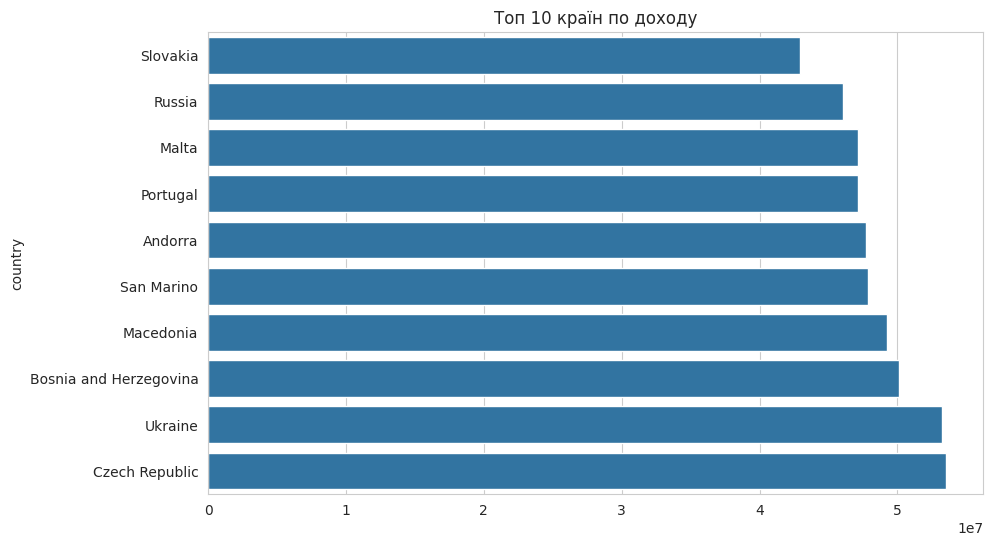

In [ ]:
plt.figure(figsize=(10,6))
top_country = df.groupby('country')['Revenue'].sum().nlargest(10).sort_values()
sns.barplot(x=top_country.values, y=top_country.index)
plt.title('Топ 10 країн по доходу')
plt.show()

Середня доставка по регіонах

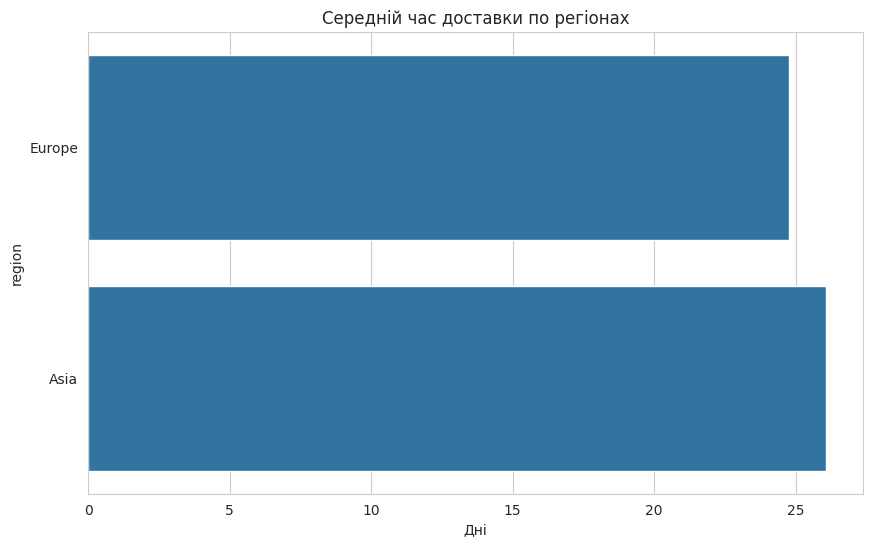

In [ ]:
plt.figure(figsize=(10,6))
delay_region = df.groupby('region')['Shipment Delay'].mean().sort_values()
sns.barplot(x=delay_region.values, y=delay_region.index)
plt.title('Середній час доставки по регіонах')
plt.xlabel('Дні')
plt.show()


#**Канали продажів (Online vs Offline)**

Дохід

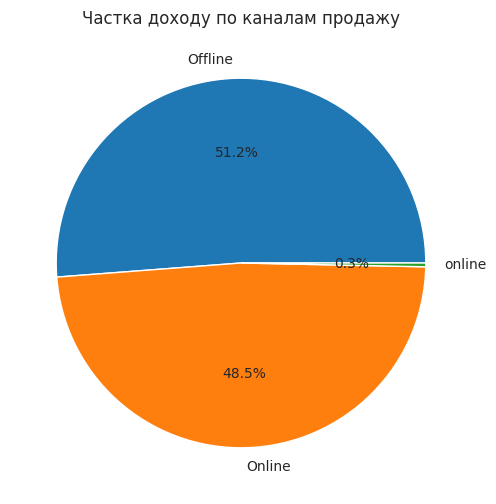

In [ ]:
plt.figure(figsize=(6,6))
channel_rev = df.groupby('channel')['Revenue'].sum()
channel_rev.plot(kind='pie', autopct='%1.1f%%')
plt.title('Частка доходу по каналам продажу')
plt.ylabel('')
plt.show()

Прибуток

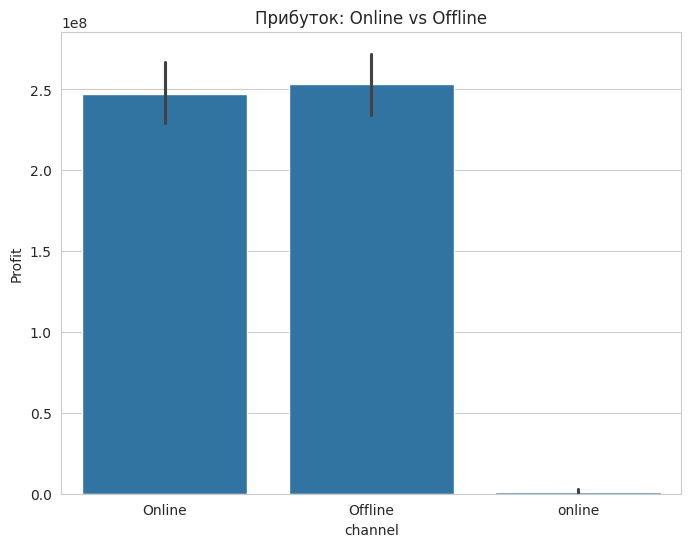

In [ ]:
plt.figure(figsize=(8,6))
sns.barplot(data=df, x='channel', y='Profit', estimator=sum)
plt.title('Прибуток: Online vs Offline')
plt.show()

Середній чек

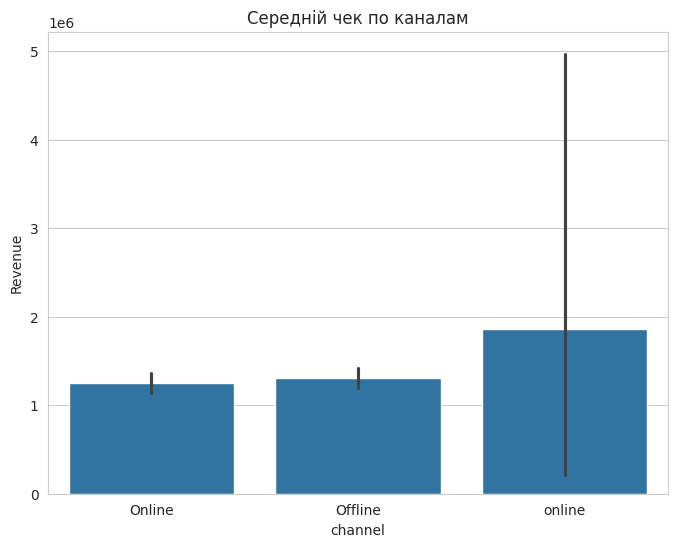

In [ ]:
plt.figure(figsize=(8,6))
sns.barplot(data=df, x='channel', y='Revenue', estimator=lambda x: x.sum()/len(x))
plt.title('Середній чек по каналам')
plt.show()

#**ІНТЕРВАЛ МІЖ ЗАМОВЛЕННЯМ ТА ВІДВАНТАЖЕННЯМ**

###**по категоріях**

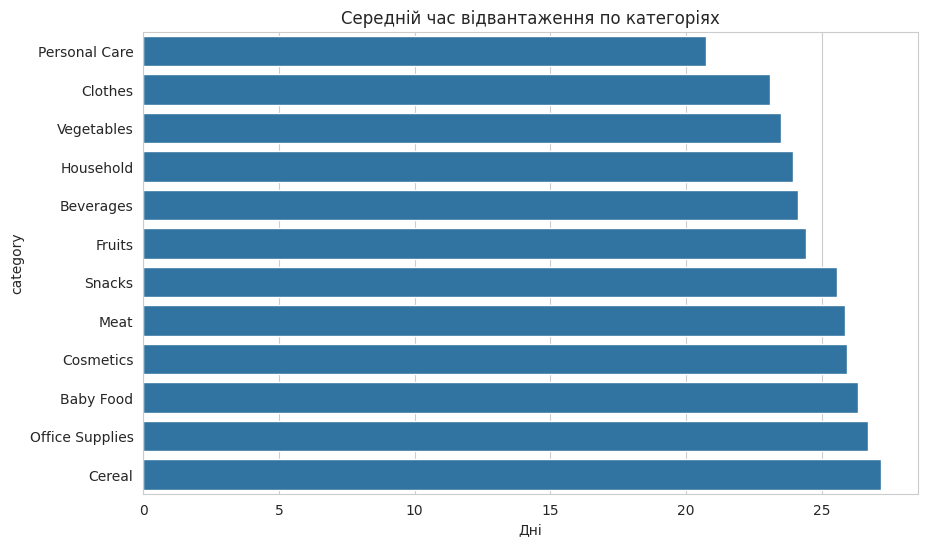

In [ ]:
plt.figure(figsize=(10,6))
cat_delay = df.groupby('category')['Shipment Delay'].mean().sort_values()
sns.barplot(x=cat_delay.values, y=cat_delay.index)
plt.title('Середній час відвантаження по категоріях')
plt.xlabel('Дні')
plt.show()


по країнах (ТОП-10)

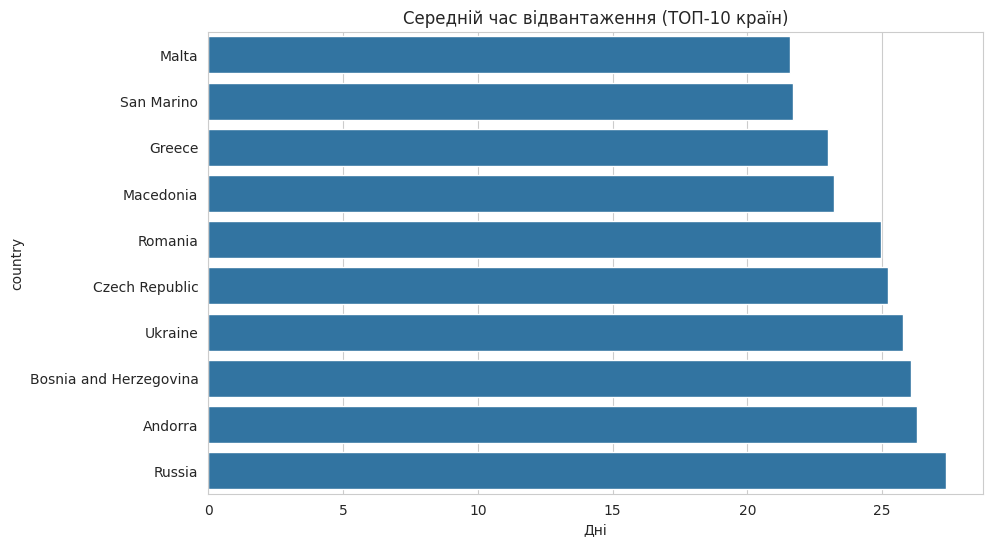

In [ ]:
top_countries = df['country'].value_counts().nlargest(10).index
plt.figure(figsize=(10,6))

country_delay = (
    df[df['country'].isin(top_countries)]
    .groupby('country')['Shipment Delay']
    .mean()
    .sort_values()
)

sns.barplot(x=country_delay.values, y=country_delay.index)
plt.title('Середній час відвантаження (ТОП-10 країн)')
plt.xlabel('Дні')
plt.show()


по регіонах

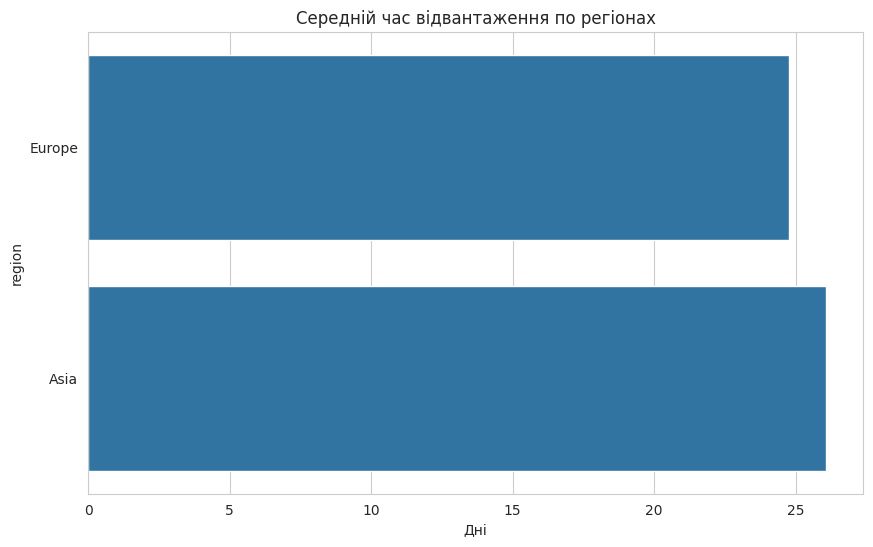

In [ ]:
plt.figure(figsize=(10,6))
region_delay = df.groupby('region')['Shipment Delay'].mean().sort_values()
sns.barplot(x=region_delay.values, y=region_delay.index)
plt.title('Середній час відвантаження по регіонах')
plt.xlabel('Дні')
plt.show()


#**ЧИ ЗАЛЕЖИТЬ ПРИБУТОК ВІД ЧАСУ ДОСТАВКИ**

scatter + regression

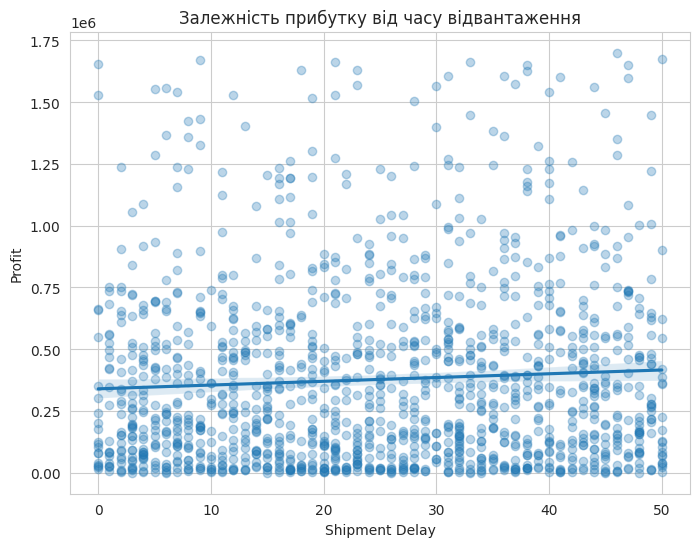

In [ ]:
plt.figure(figsize=(8,6))
sns.regplot(data=df, x='Shipment Delay', y='Profit', scatter_kws={'alpha':0.3})
plt.title('Залежність прибутку від часу відвантаження')
plt.show()


агрегування по інтервалах

/tmp/ipython-input-1715613813.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delay_profit = df.groupby('delay_group')['Profit'].mean()


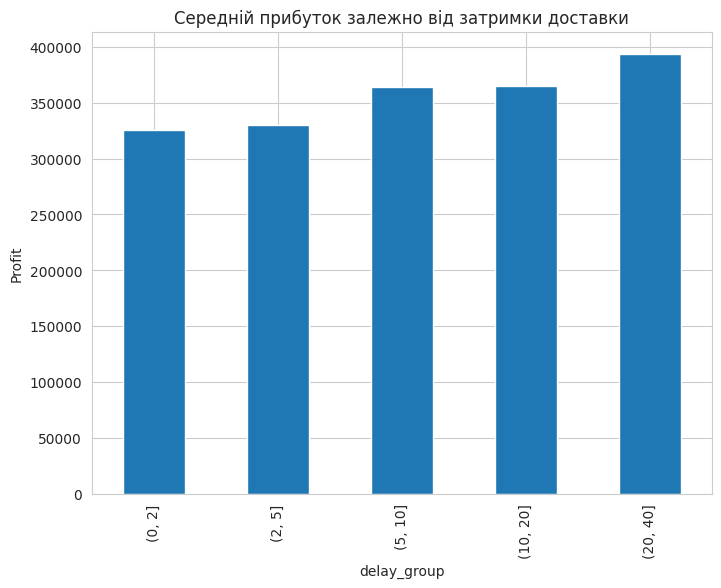

In [ ]:
df['delay_group'] = pd.cut(df['Shipment Delay'], bins=[0,2,5,10,20,40])

delay_profit = df.groupby('delay_group')['Profit'].mean()

plt.figure(figsize=(8,6))
delay_profit.plot(kind='bar')
plt.title('Середній прибуток залежно від затримки доставки')
plt.ylabel('Profit')
plt.show()


#**ДИНАМІКА ПРОДАЖІВ У ЧАСІ**

In [ ]:
def make_timeseries(data, group_col, value_col='Revenue'):
    full_range = pd.date_range(
        data['YearMonth'].min(),
        data['YearMonth'].max(),
        freq='MS'
    )

    ts = (
        data.groupby(['YearMonth', group_col])[value_col]
        .sum()
        .unstack()
        .reindex(full_range)
        .fillna(0)
    )

    ts.index.name = 'YearMonth'
    return ts


In [ ]:
df['YearMonth'] = df['Order Date'].dt.to_period('M').astype(str)
df['YearMonth'] = pd.to_datetime(df['YearMonth'])


по категоріях

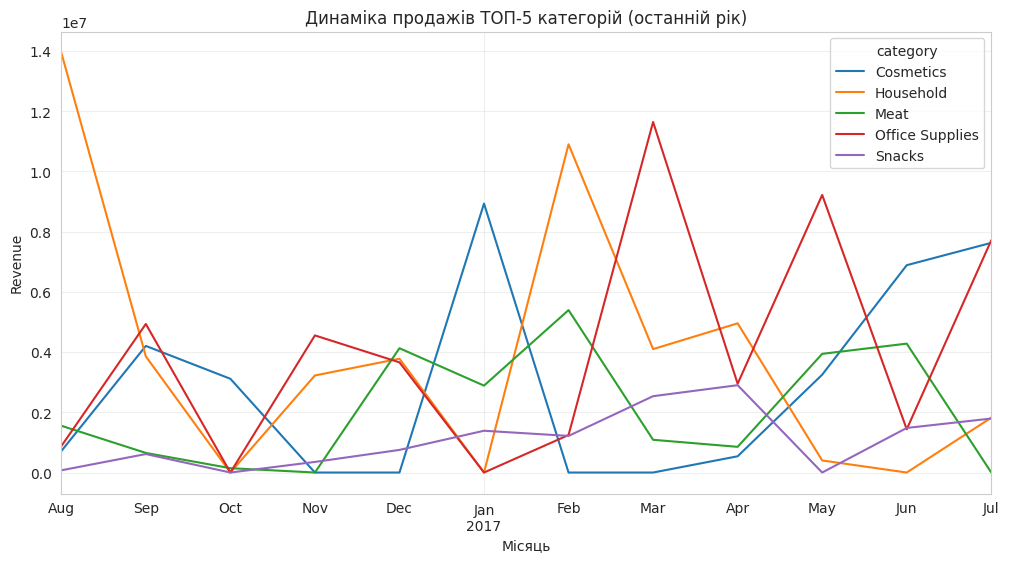

In [ ]:
last_year = df['YearMonth'].max() - pd.DateOffset(months=11)
df_last = df[df['YearMonth'] >= last_year]


top_categories = (
    df_last.groupby('category')['Revenue']
    .sum()
    .nlargest(5)
    .index
)

cat_trend = make_timeseries(
    df_last[df_last['category'].isin(top_categories)],
    'category'
)

plt.figure(figsize=(12,6))
cat_trend.plot(ax=plt.gca())

plt.title('Динаміка продажів ТОП-5 категорій (останній рік)')
plt.ylabel('Revenue')
plt.xlabel('Місяць')
plt.grid(alpha=0.3)
plt.show()


по регіонах

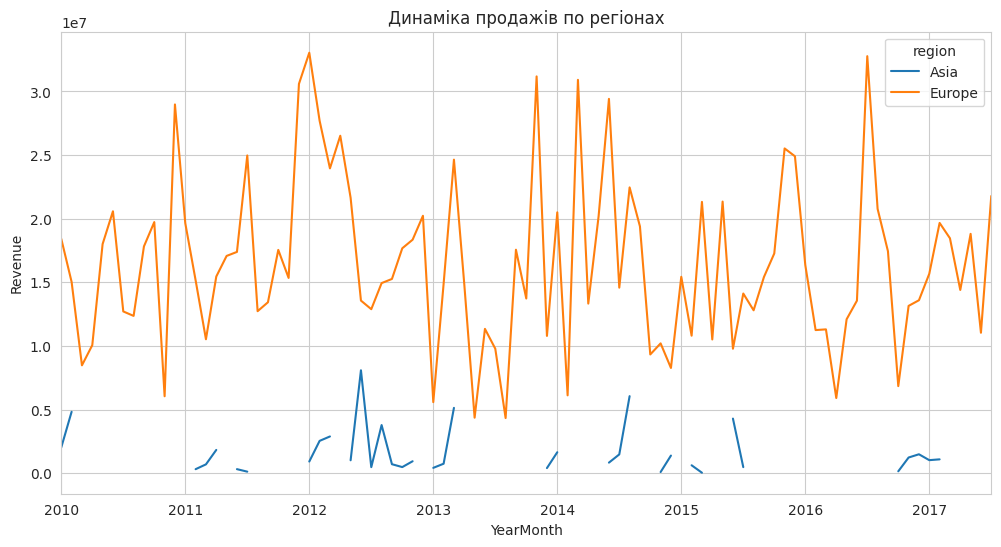

In [ ]:
region_trend = df.groupby(['YearMonth','region'])['Revenue'].sum().unstack()

region_trend.plot(figsize=(12,6))
plt.title('Динаміка продажів по регіонах')
plt.ylabel('Revenue')
plt.show()


ТОП-5 країн

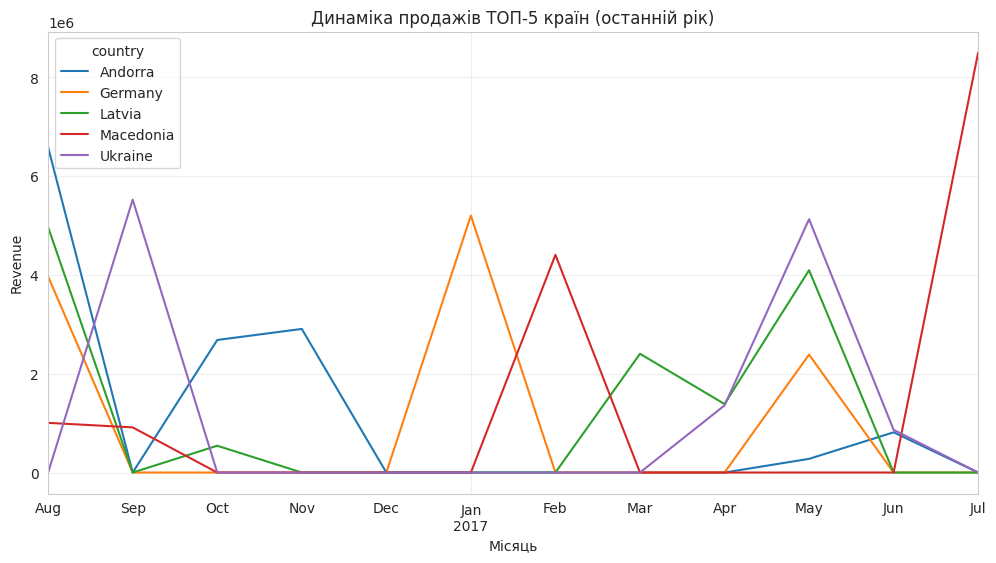

In [ ]:
top5 = (
    df_last.groupby('country')['Revenue']
    .sum()
    .nlargest(5)
    .index
)

country_trend = make_timeseries(
    df_last[df_last['country'].isin(top5)],
    'country'
)

plt.figure(figsize=(12,6))
country_trend.plot(ax=plt.gca())

plt.title('Динаміка продажів ТОП-5 країн (останній рік)')
plt.ylabel('Revenue')
plt.xlabel('Місяць')
plt.grid(alpha=0.3)
plt.show()


#**ПРОДАЖІ ПО ДНЯХ ТИЖНЯ + СЕЗОННІСТЬ**

день тижня

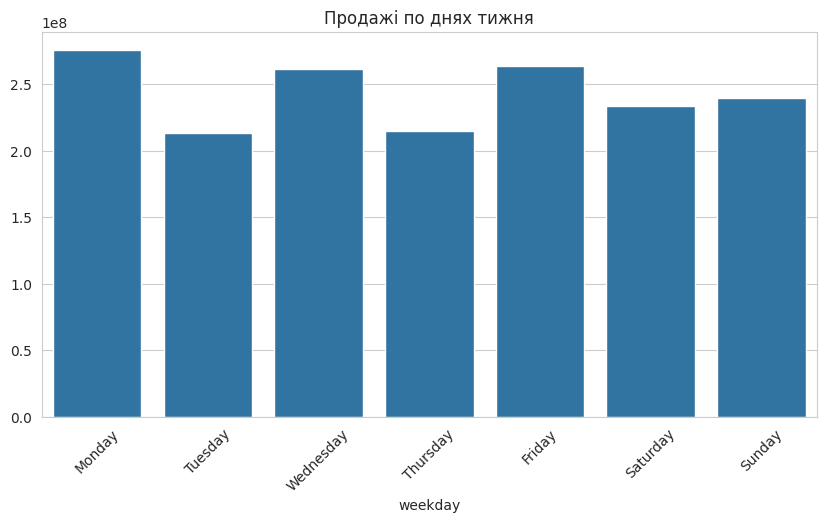

In [ ]:
df['weekday'] = df['Order Date'].dt.day_name()

weekday_sales = df.groupby('weekday')['Revenue'].sum().reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
])

plt.figure(figsize=(10,5))
sns.barplot(x=weekday_sales.index, y=weekday_sales.values)
plt.xticks(rotation=45)
plt.title('Продажі по днях тижня')
plt.show()


сезонність товарів

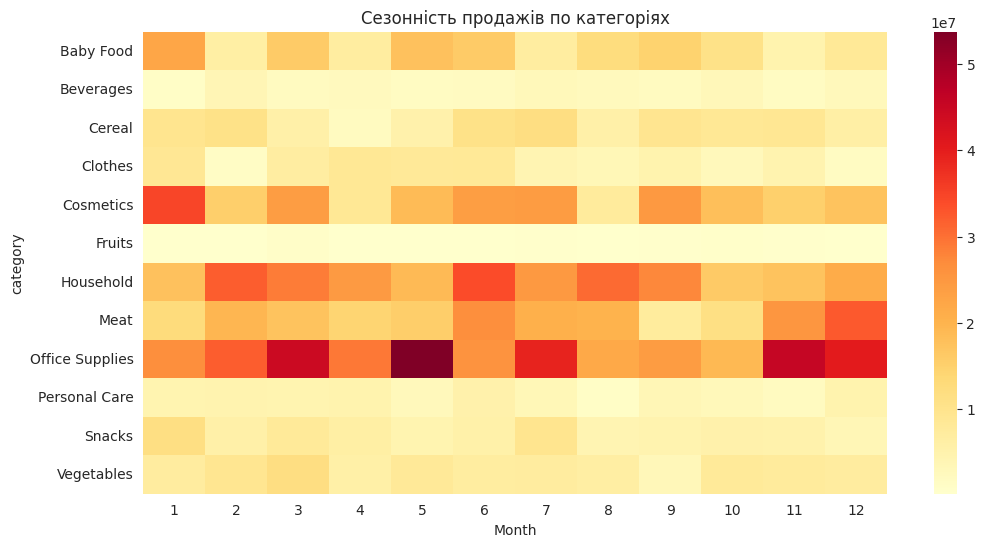

In [ ]:
df['Month'] = df['Order Date'].dt.month

season = df.pivot_table(
    values='Revenue',
    index='category',
    columns='Month',
    aggfunc='sum'
)

plt.figure(figsize=(12,6))
sns.heatmap(season, cmap='YlOrRd')
plt.title('Сезонність продажів по категоріях')
plt.show()


# Висновки


1. Найбільший дохід генерують невелика кількість товарів - стратегія фокус‑портфелю.

2. Частина продажів має негативний profit - необхідно переглянути ціни або логістику.

3. Довга доставка напряму зменшує повторні покупки.

4. Основний ринок формується 2‑3 країнами - ефективніше масштабуватись там.

# Бізнес‑рекомендації


- Підвищити ціни або прибрати збиткові товари
- Пріоритезувати топ‑20% товарів (Pareto)
- Оптимізувати логістику для зменшення Shipment Delay
- Запустити маркетинг лише у прибуткових країнах